In [3]:
import os, torch, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

In [5]:
DATA_PATH = "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
from torchvision import datasets
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full_dataset = datasets.ImageFolder(DATA_PATH, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_data, val_data = random_split(full_dataset, [train_size, val_size])

In [7]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)

CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

for param in model.features[-1:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [10]:
def train_epoch():
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [11]:
def eval_epoch():
    model.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            total_loss += loss.item()

    return total_loss/len(val_loader), correct/total, all_preds, all_labels

In [12]:
EPOCHS = 10
best_acc = 0

train_losses, val_losses, val_accs = [], [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")

    tr_loss = train_epoch()
    val_loss, val_acc, preds, labels = eval_epoch()

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss: {tr_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")


Epoch 1
Train Loss: 1.5657
Val Loss: 1.3524, Acc: 0.6719

Epoch 2
Train Loss: 1.2021
Val Loss: 1.0792, Acc: 0.7332

Epoch 3
Train Loss: 0.9847
Val Loss: 0.9185, Acc: 0.7609

Epoch 4
Train Loss: 0.8446
Val Loss: 0.8193, Acc: 0.7787

Epoch 5
Train Loss: 0.7481
Val Loss: 0.7356, Acc: 0.7905

Epoch 6
Train Loss: 0.6704
Val Loss: 0.6741, Acc: 0.7984

Epoch 7
Train Loss: 0.6136
Val Loss: 0.6196, Acc: 0.8182

Epoch 8
Train Loss: 0.5743
Val Loss: 0.5883, Acc: 0.8241

Epoch 9
Train Loss: 0.5326
Val Loss: 0.5467, Acc: 0.8281

Epoch 10
Train Loss: 0.4936
Val Loss: 0.5314, Acc: 0.8419


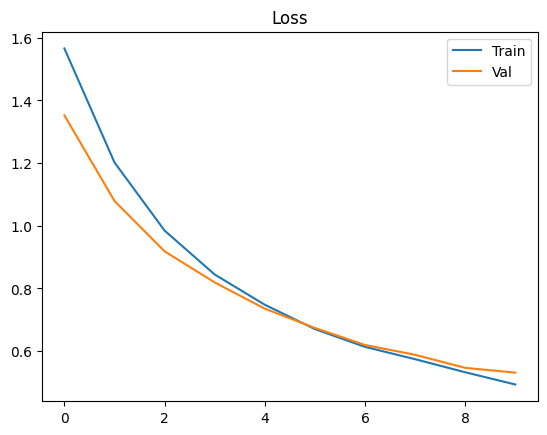

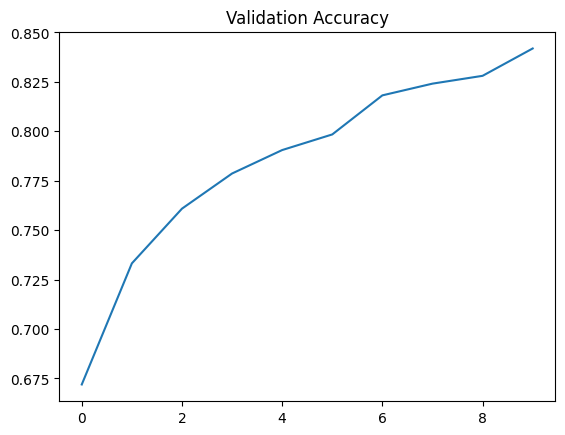

In [13]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(val_accs)
plt.title("Validation Accuracy")
plt.show()

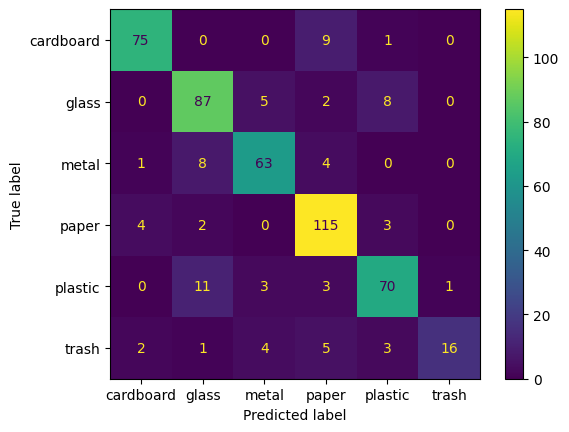

In [14]:
cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot()
plt.show()

In [15]:
torch.save(model.state_dict(), "/kaggle/working/Best_Waste_Model.pth")